In [31]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [32]:
train_dir = "/content/drive/MyDrive/RA0001/DATA Emoji RA0001"
img_width,img_height= 200,200
batch_size = 128
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical')

Found 2251 images belonging to 39 classes.


In [33]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (200,200,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dropout(0.5),
    Dense(39,activation = 'softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,765,543 (33.44 MB)

 Trainable params: 8,765,543 (33.44 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(train_generator,epochs = 10)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 242s 13s/step - accuracy: 0.0835 - loss: 3.4861
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 250s 14s/step - accuracy: 0.1177 - loss: 3.2233
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 241s 13s/step - accuracy: 0.2035 - loss: 2.9258
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 279s 14s/step - accuracy: 0.2657 - loss: 2.6583
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 242s 13s/step - accuracy: 0.3110 - loss: 2.4434
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 241s 13s/step - accuracy: 0.3527 - loss: 2.2813
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 257s 14s/step - accuracy: 0.3816 - loss: 2.1067
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 242s 13s/step - accuracy: 0.4114 - loss: 1.9879
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 253s 14s/step - accuracy: 0.4620 - loss: 1.8337
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 242s 13s/step - accuracy: 0.4869 - loss: 1.7176


In [37]:
model.save('model.h5')

In [ ]:
from keras.models import load_model
model = load_model('model.h5')

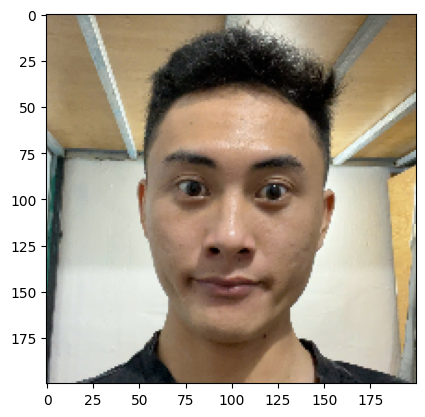

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Họ và tên : 21_Ninh Công Uy_31251025315


In [36]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path ="/content/anh_test.jpg"
img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200, 200, 3)
prediction=np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Họ và tên : {person_name}")